# Demo: reproduce Fig 2A from the public inputs

A small, **self-contained** notebook that actually runs on the shared atlas object to
(1) verify the headline numbers against the paper and (2) reproduce **Fig. 2A** (global
mCG per major type). It only needs `clustering/merged/5kCG100k3C_summary.h5ad` and
`L1color.tsv`, so it executes in seconds — the pattern every other notebook follows.


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')
import repro_guard
indir = f'{ENTEX_ROOT}/'

[repro_guard] active — no-overwrite (existing files are cached/skipped)


In [2]:
import anndata, numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns
mpl.rcParams['pdf.fonttype']=42; mpl.rcParams['ps.fonttype']=42
mpl.rcParams['font.family']='sans-serif'
import warnings; warnings.filterwarnings('ignore')

## Verify the headline numbers against the paper

Abstract: **86,689 nuclei · 35 major types · 206 subtypes · 16 tissues**.


In [3]:
adata = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad')
obs = adata.obs
print('cells      :', adata.n_obs,            '(paper: 86,689)')
print('major types:', obs['L1_annot'].nunique(), '(paper: 35)')
print('tissues    :', obs['Tissue'].nunique(),   '(paper: 16)')

cells      : 86689 (paper: 86,689)
major types: 35 (paper: 35)
tissues    : 16 (paper: 16)


Per-tissue cell counts printed in Fig. 1 (labels differ slightly; counts are exact):


In [4]:
paper = {'Adrenal Gland':5690,'Breast':5299,'Esophagus':5949,'Lung':5124,
  'Pancreatic Islet':4700,'Peripheral Blood':5780,'Placenta':5731,'Primary Motor Cortex':8225,
  'Skeletal Muscle':5569,'Skin':4353,'Small Intestine':3067,'Stomach':5982,
  'Tibial Nerve':4860,'Transverse Colon':5836,'Left Ventricle':5697,'Right Atrium Appendage':4827}
vc = obs['tissue_annot'].value_counts().to_dict()
chk = pd.DataFrame({'code':[vc.get(t) for t in paper], 'paper':list(paper.values())}, index=paper)
chk['match'] = chk['code']==chk['paper']
print(chk); print('\nall match:', bool(chk['match'].all()), '| total:', int(chk['code'].sum()))

                        code  paper  match
Adrenal Gland           5690   5690   True
Breast                  5299   5299   True
Esophagus               5949   5949   True
Lung                    5124   5124   True
Pancreatic Islet        4700   4700   True
Peripheral Blood        5780   5780   True
Placenta                5731   5731   True
Primary Motor Cortex    8225   8225   True
Skeletal Muscle         5569   5569   True
Skin                    4353   4353   True
Small Intestine         3067   3067   True
Stomach                 5982   5982   True
Tibial Nerve            4860   4860   True
Transverse Colon        5836   5836   True
Left Ventricle          5697   5697   True
Right Atrium Appendage  4827   4827   True

all match: True | total: 86689


## Reproduce Fig. 2A — global mCG per major type

Boxplot of per-cell genome-wide mCG (`mCGFrac`), major types ordered by median mCG.
Trophoblast / PMD-rich epithelia sit lowest; neurons highest — as in the paper.


lowest : ['Epi TPB', 'Hema B', 'Epi Aci']
highest: ['Hema NK', 'Hema Tnaive', 'Neu Inh']


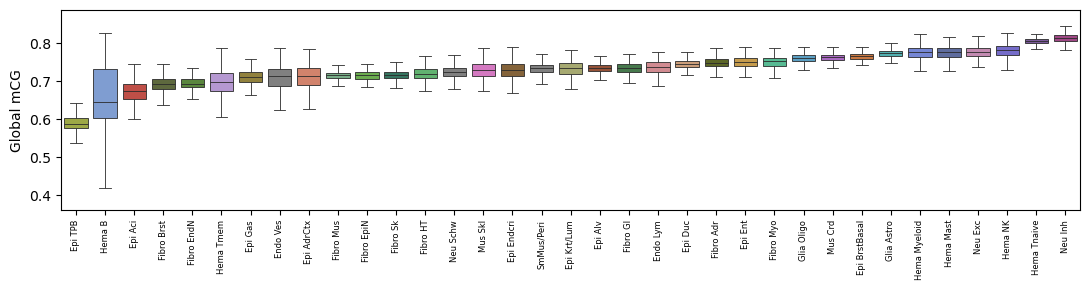

In [5]:
L1 = pd.read_csv(f'{indir}L1color.tsv', sep='\t', index_col=0)
abbr2color = {r['L1_abbr']: r['color'] for _, r in L1.iterrows()}
order = obs.groupby('L1_annot')['mCGFrac'].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(11,3))
sns.boxplot(data=obs, x='L1_annot', y='mCGFrac', order=order, hue='L1_annot',
            palette={t:abbr2color.get(t,'grey') for t in order}, legend=False,
            fliersize=0, linewidth=.6, ax=ax)
ax.set_xticklabels(order, rotation=90, fontsize=6)
ax.set_ylabel('Global mCG'); ax.set_xlabel(''); fig.tight_layout()
print('lowest :', order[:3]); print('highest:', order[-3:])

## Reproduce Fig. 3A — global mCH per major type

Neuronal types (Neu Exc/Inh) carry ~10× the mCH of non-neuronal types, so the plot is
split; here we simply show the ordering to verify.


lowest mCH : ['Epi Duc', 'Epi Krt/Lum', 'Epi Aci']
highest mCH: ['Glia Astro', 'Neu Exc', 'Neu Inh'] (expect Neu Inh / Neu Exc on top)


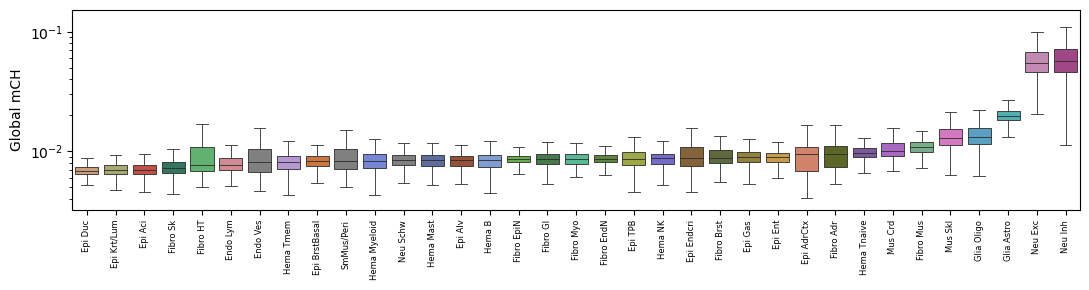

In [6]:
order_ch = obs.groupby('L1_annot')['mCHFrac'].median().sort_values()
print('lowest mCH :', order_ch.index[:3].tolist())
print('highest mCH:', order_ch.index[-3:].tolist(), '(expect Neu Inh / Neu Exc on top)')
fig, ax = plt.subplots(figsize=(11,3))
sns.boxplot(data=obs, x='L1_annot', y='mCHFrac', order=order_ch.index.tolist(), hue='L1_annot',
            palette={t:abbr2color.get(t,'grey') for t in order_ch.index}, legend=False,
            fliersize=0, linewidth=.6, ax=ax)
ax.set_xticklabels(order_ch.index.tolist(), rotation=90, fontsize=6)
ax.set_ylabel('Global mCH'); ax.set_xlabel(''); ax.set_yscale('log'); fig.tight_layout()

## Reproduce Fig. 1E — tissue composition per major type


tissues per major type add to 1: True


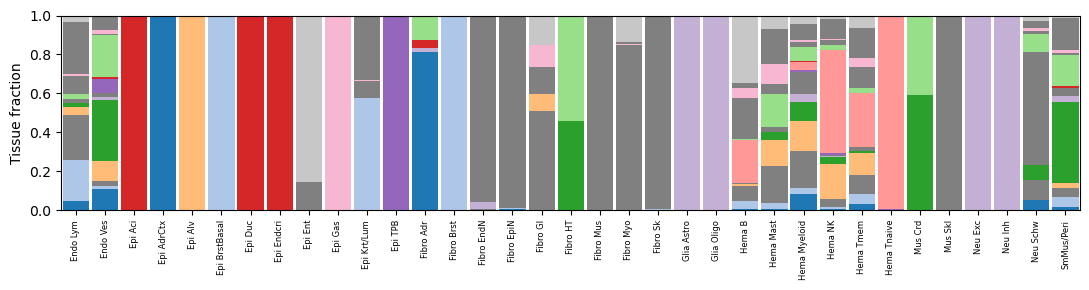

In [7]:
tis = pd.crosstab(obs['L1_annot'], obs['tissue_annot'], normalize='index')
tcol = pd.read_csv(f'{indir}tissuecolor.tsv', sep='\t', index_col=0)
t2c = {r.get('tissue_annot', i): r['color'] for i,r in tcol.iterrows()} if 'tissue_annot' in tcol else {}
cols = [c for c in tis.columns]
fig, ax = plt.subplots(figsize=(11,3)); bottom = np.zeros(len(tis))
for c in cols:
    ax.bar(range(len(tis)), tis[c].values, bottom=bottom, width=.9,
           color=t2c.get(c,'grey'), label=c)
    bottom += tis[c].values
ax.set_xticks(range(len(tis))); ax.set_xticklabels(tis.index, rotation=90, fontsize=6)
ax.set_ylabel('Tissue fraction'); ax.set_xlim(-.5,len(tis)-.5); fig.tight_layout()
print('tissues per major type add to 1:', bool(np.allclose(bottom,1)))